In [54]:
import pandas as pd
import sqlite3

In [55]:
url = "https://raw.githubusercontent.com/hemanthkarthikd/procurement-supplier-analytics/main/data/raw/procurement_transactions.csv"

df = pd.read_csv(url)

df.head()

,po_number,order_date,supplier_id,supplier_name,supplier_region,category,material_id,quantity_ordered,quantity_received,standard_unit_price,actual_unit_price,order_value,promised_delivery_date,actual_delivery_date,defective_units,payment_terms,buyer,plant
0,PO100000,2024-08-28,SUP001,Apex Industrial,North America,Raw Metals,MAT4157,115,114,175.40,185.77,21363.55,2024-09-21,2024-09-20,1,Net 45,Buyer B,Boston Plant
1,PO100001,2025-10-07,SUP005,Global Fasteners,North America,Fasteners,MAT7776,1383,1369,223.68,229.03,316748.49,2025-11-13,2025-11-13,87,Net 30,Buyer A,Dallas Plant
2,PO100002,2025-03-31,SUP001,Apex Industrial,North America,Fasteners,MAT4763,337,337,59.42,61.79,20823.23,2025-04-24,2025-04-24,12,Net 30,Buyer B,Boston Plant
3,PO100003,2024-09-24,SUP004,Precision Parts,Europe,Raw Metals,MAT6791,1429,1407,179.51,178.82,255533.78,2024-11-04,2024-11-06,43,Net 45,Buyer D,Dallas Plant
4,PO100004,2024-07-21,SUP013,Evergreen Materials,Asia,Raw Metals,MAT5282,420,415,183.41,198.49,83365.80,2024-08-05,2024-07-29,15,Net 45,Buyer D,Boston Plant


In [56]:
df.shape

(25000, 18)

In [57]:
conn = sqlite3.connect("procurement.db")

df.to_sql(
    "procurement_transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")

Database created successfully.


In [58]:
query = """
SELECT *
FROM procurement_transactions
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,po_number,order_date,supplier_id,supplier_name,supplier_region,category,material_id,quantity_ordered,quantity_received,standard_unit_price,actual_unit_price,order_value,promised_delivery_date,actual_delivery_date,defective_units,payment_terms,buyer,plant
0,PO100000,2024-08-28,SUP001,Apex Industrial,North America,Raw Metals,MAT4157,115,114,175.40,185.77,21363.55,2024-09-21,2024-09-20,1,Net 45,Buyer B,Boston Plant
1,PO100001,2025-10-07,SUP005,Global Fasteners,North America,Fasteners,MAT7776,1383,1369,223.68,229.03,316748.49,2025-11-13,2025-11-13,87,Net 30,Buyer A,Dallas Plant
2,PO100002,2025-03-31,SUP001,Apex Industrial,North America,Fasteners,MAT4763,337,337,59.42,61.79,20823.23,2025-04-24,2025-04-24,12,Net 30,Buyer B,Boston Plant
3,PO100003,2024-09-24,SUP004,Precision Parts,Europe,Raw Metals,MAT6791,1429,1407,179.51,178.82,255533.78,2024-11-04,2024-11-06,43,Net 45,Buyer D,Dallas Plant
4,PO100004,2024-07-21,SUP013,Evergreen Materials,Asia,Raw Metals,MAT5282,420,415,183.41,198.49,83365.80,2024-08-05,2024-07-29,15,Net 45,Buyer D,Boston Plant


In [59]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT po_number) AS unique_po_numbers,
    COUNT(DISTINCT supplier_id) AS suppliers,
    COUNT(DISTINCT category) AS categories,
    COUNT(DISTINCT plant) AS plants
FROM procurement_transactions;
"""

pd.read_sql_query(query, conn)

,total_rows,unique_po_numbers,suppliers,categories,plants
0,25000,25000,25,6,3


In [60]:
query = """
SELECT
    SUM(CASE WHEN po_number IS NULL THEN 1 ELSE 0 END) AS missing_po,
    SUM(CASE WHEN supplier_id IS NULL THEN 1 ELSE 0 END) AS missing_supplier,
    SUM(CASE WHEN order_date IS NULL THEN 1 ELSE 0 END) AS missing_order_date,
    SUM(CASE WHEN quantity_ordered IS NULL THEN 1 ELSE 0 END) AS missing_quantity,
    SUM(CASE WHEN actual_unit_price IS NULL THEN 1 ELSE 0 END) AS missing_price
FROM procurement_transactions;
"""

pd.read_sql_query(query, conn)

,missing_po,missing_supplier,missing_order_date,missing_quantity,missing_price
0,0,0,0,0,0


In [61]:
query = """
SELECT
    *,

    CAST(
        julianday(actual_delivery_date) -
        julianday(promised_delivery_date)
        AS INTEGER
    ) AS days_late,

    CASE
        WHEN julianday(actual_delivery_date) <= julianday(promised_delivery_date)
        THEN 1
        ELSE 0
    END AS on_time_delivery,

    ROUND(
        (quantity_received * 100.0) / quantity_ordered,
        2
    ) AS fill_rate_pct,

    CASE
        WHEN quantity_received >= quantity_ordered
        THEN 1
        ELSE 0
    END AS in_full,

    CASE
        WHEN julianday(actual_delivery_date) <= julianday(promised_delivery_date)
             AND quantity_received >= quantity_ordered
        THEN 1
        ELSE 0
    END AS otif,

    ROUND(
        (defective_units * 100.0) / NULLIF(quantity_received, 0),
        2
    ) AS defect_rate_pct,

    ROUND(
        actual_unit_price - standard_unit_price,
        2
    ) AS price_variance_per_unit,

    ROUND(
        ((actual_unit_price - standard_unit_price)
        / NULLIF(standard_unit_price, 0)) * 100,
        2
    ) AS price_variance_pct,

    CAST(
        julianday(actual_delivery_date) -
        julianday(order_date)
        AS INTEGER
    ) AS actual_lead_time_days

FROM procurement_transactions;
"""

metrics_df = pd.read_sql_query(query, conn)

metrics_df.head()

,po_number,order_date,supplier_id,supplier_name,supplier_region,category,material_id,quantity_ordered,quantity_received,standard_unit_price,...,plant,days_late,on_time_delivery,fill_rate_pct,in_full,otif,defect_rate_pct,price_variance_per_unit,price_variance_pct,actual_lead_time_days
0,PO100000,2024-08-28,SUP001,Apex Industrial,North America,Raw Metals,MAT4157,115,114,175.40,...,Boston Plant,-1,1,99.13,0,0,0.88,10.37,5.91,23
1,PO100001,2025-10-07,SUP005,Global Fasteners,North America,Fasteners,MAT7776,1383,1369,223.68,...,Dallas Plant,0,1,98.99,0,0,6.36,5.35,2.39,37
2,PO100002,2025-03-31,SUP001,Apex Industrial,North America,Fasteners,MAT4763,337,337,59.42,...,Boston Plant,0,1,100.00,1,1,3.56,2.37,3.99,24
3,PO100003,2024-09-24,SUP004,Precision Parts,Europe,Raw Metals,MAT6791,1429,1407,179.51,...,Dallas Plant,2,0,98.46,0,0,3.06,-0.69,-0.38,43
4,PO100004,2024-07-21,SUP013,Evergreen Materials,Asia,Raw Metals,MAT5282,420,415,183.41,...,Boston Plant,-7,1,98.81,0,0,3.61,15.08,8.22,8


In [62]:
metrics_df[
    [
        "days_late",
        "fill_rate_pct",
        "defect_rate_pct",
        "price_variance_pct",
        "actual_lead_time_days"
    ]
].describe()

,days_late,fill_rate_pct,defect_rate_pct,price_variance_pct,actual_lead_time_days
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2.721600,99.003463,2.476140,3.086400,29.662000
std,5.745932,0.787313,1.839532,4.859394,11.551085
min,-19.000000,90.320000,0.000000,-14.740000,1.000000
25%,-1.000000,98.510000,0.930000,-0.230000,21.000000
50%,3.000000,99.090000,2.400000,2.930000,30.000000
75%,7.000000,99.630000,3.430000,6.000000,38.000000
max,27.000000,100.000000,20.000000,24.340000,63.000000


In [63]:
metrics_df[
    [
        "po_number",
        "supplier_name",
        "quantity_ordered",
        "quantity_received",
        "days_late",
        "on_time_delivery",
        "fill_rate_pct",
        "in_full",
        "otif",
        "defect_rate_pct",
        "price_variance_pct"
    ]
].head(10)

,po_number,supplier_name,quantity_ordered,quantity_received,days_late,on_time_delivery,fill_rate_pct,in_full,otif,defect_rate_pct,price_variance_pct
0,PO100000,Apex Industrial,115,114,-1,1,99.13,0,0,0.88,5.91
1,PO100001,Global Fasteners,1383,1369,0,1,98.99,0,0,6.36,2.39
2,PO100002,Apex Industrial,337,337,0,1,100.00,1,1,3.56,3.99
3,PO100003,Precision Parts,1429,1407,2,0,98.46,0,0,3.06,-0.38
4,PO100004,Evergreen Materials,420,415,-7,1,98.81,0,0,3.61,8.22
5,PO100005,Crown Industrial,166,163,-9,1,98.19,0,0,1.84,6.66
6,PO100006,Titan Metals,1036,1025,11,0,98.94,0,0,3.41,-2.00
7,PO100007,Metro Industrial,1463,1456,-3,1,99.52,0,0,1.10,5.90
8,PO100008,Apex Industrial,1435,1419,13,0,98.89,0,0,3.38,7.49
9,PO100009,Prime Plastics,303,298,3,0,98.35,0,0,0.00,2.74


In [64]:
df["actual_delivery_date"] = pd.to_datetime(df["actual_delivery_date"])
df["order_date"] = pd.to_datetime(df["order_date"])

(df["actual_delivery_date"] - df["order_date"]).dt.days.min()

1

In [65]:
import pandas as pd
import sqlite3

In [66]:
import pandas as pd
import sqlite3

url = "https://raw.githubusercontent.com/hemanthkarthikd/procurement-supplier-analytics/main/data/raw/procurement_transactions.csv"

df = pd.read_csv(url)

print(df.shape)

(25000, 18)


In [67]:
df["actual_delivery_date"] = pd.to_datetime(df["actual_delivery_date"])
df["order_date"] = pd.to_datetime(df["order_date"])

print((df["actual_delivery_date"] - df["order_date"]).dt.days.min())

1


In [68]:
conn = sqlite3.connect("procurement.db")

df.to_sql(
    "procurement_transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Database updated successfully.")

Database updated successfully.


In [69]:
query = """
SELECT COUNT(*) AS total_rows
FROM procurement_transactions;
"""

pd.read_sql_query(query, conn)

,total_rows
0,25000


In [70]:
query = """
SELECT
    ROUND(SUM(order_value), 2) AS total_procurement_spend,
    COUNT(*) AS total_purchase_orders,
    COUNT(DISTINCT supplier_id) AS total_suppliers
FROM procurement_transactions;
"""

pd.read_sql_query(query, conn)

,total_procurement_spend,total_purchase_orders,total_suppliers
0,2.478892e+09,25000,25


Top 10 suppliers by spend:

In [71]:
query = """
SELECT
    supplier_id,
    supplier_name,
    COUNT(*) AS purchase_orders,
    ROUND(SUM(order_value), 2) AS total_spend,
    ROUND(AVG(order_value), 2) AS avg_po_value
FROM procurement_transactions
GROUP BY supplier_id, supplier_name
ORDER BY total_spend DESC;
"""

supplier_spend = pd.read_sql_query(query, conn)

supplier_spend.head(10)

,supplier_id,supplier_name,purchase_orders,total_spend,avg_po_value
0,SUP001,Apex Industrial,2186,2.181400e+08,99789.55
1,SUP002,Nova Components,1838,1.942634e+08,105692.83
2,SUP003,Titan Metals,1771,1.706732e+08,96371.07
3,SUP004,Precision Parts,1484,1.476003e+08,99461.09
4,SUP005,Global Fasteners,1511,1.423732e+08,94224.48
5,SUP009,Summit Electronics,1236,1.362093e+08,110201.70
6,SUP006,Vertex Manufacturing,1228,1.275311e+08,103852.71
7,SUP007,Prime Plastics,1220,1.220005e+08,100000.39
8,SUP008,Atlas Steel,1258,1.164510e+08,92568.35
9,SUP012,Metro Industrial,980,9.633076e+07,98296.70


analyzing spend by category:

In [72]:
query = """
SELECT
    category,
    COUNT(*) AS purchase_orders,
    ROUND(SUM(order_value), 2) AS total_spend,
    ROUND(AVG(order_value), 2) AS avg_po_value
FROM procurement_transactions
GROUP BY category
ORDER BY total_spend DESC;
"""

category_spend = pd.read_sql_query(query, conn)

category_spend

,category,purchase_orders,total_spend,avg_po_value
0,Machined Components,5425,5.298933e+08,97676.19
1,Raw Metals,4817,4.819177e+08,100045.20
2,Fasteners,4303,4.322051e+08,100442.73
3,Electronics,3768,3.695692e+08,98081.01
4,Plastics,3582,3.611429e+08,100821.57
5,Packaging,3105,3.041637e+08,97959.34


ABC supplier classification:

In [73]:
query = """
WITH supplier_spend AS (
    SELECT
        supplier_id,
        supplier_name,
        SUM(order_value) AS total_spend
    FROM procurement_transactions
    GROUP BY supplier_id, supplier_name
),

ranked AS (
    SELECT
        supplier_id,
        supplier_name,
        total_spend,

        SUM(total_spend) OVER (
            ORDER BY total_spend DESC
        ) AS cumulative_spend,

        SUM(total_spend) OVER () AS company_spend

    FROM supplier_spend
)

SELECT
    supplier_id,
    supplier_name,
    ROUND(total_spend, 2) AS total_spend,

    ROUND(
        total_spend / company_spend * 100,
        2
    ) AS spend_share_pct,

    ROUND(
        cumulative_spend / company_spend * 100,
        2
    ) AS cumulative_spend_pct,

    CASE
        WHEN cumulative_spend / company_spend <= 0.80 THEN 'A'
        WHEN cumulative_spend / company_spend <= 0.95 THEN 'B'
        ELSE 'C'
    END AS abc_class

FROM ranked

ORDER BY total_spend DESC;
"""

abc_analysis = pd.read_sql_query(query, conn)

abc_analysis

,supplier_id,supplier_name,total_spend,spend_share_pct,cumulative_spend_pct,abc_class
0,SUP001,Apex Industrial,2.181400e+08,8.80,8.80,A
1,SUP002,Nova Components,1.942634e+08,7.84,16.64,A
2,SUP003,Titan Metals,1.706732e+08,6.89,23.52,A
3,SUP004,Precision Parts,1.476003e+08,5.95,29.48,A
4,SUP005,Global Fasteners,1.423732e+08,5.74,35.22,A
5,SUP009,Summit Electronics,1.362093e+08,5.49,40.71,A
6,SUP006,Vertex Manufacturing,1.275311e+08,5.14,45.86,A
7,SUP007,Prime Plastics,1.220005e+08,4.92,50.78,A
8,SUP008,Atlas Steel,1.164510e+08,4.70,55.48,A
9,SUP012,Metro Industrial,9.633076e+07,3.89,59.36,A


A suppliers = the suppliers responsible for roughly the first 80% of spend.
B suppliers = roughly the next 15%.
C suppliers = approximately the final 5%.
This matters because an A supplier with poor delivery, quality, or pricing performance is much more strategically important than a low-spend supplier with the same issue.

In [74]:
query = """
SELECT
    supplier_id,
    supplier_name,

    COUNT(*) AS total_orders,

    ROUND(SUM(order_value), 2) AS total_spend,

    ROUND(
        AVG(
            CASE
                WHEN julianday(actual_delivery_date)
                     <= julianday(promised_delivery_date)
                THEN 100.0
                ELSE 0.0
            END
        ),
        2
    ) AS on_time_delivery_pct,

    ROUND(
        SUM(quantity_received) * 100.0
        / NULLIF(SUM(quantity_ordered), 0),
        2
    ) AS fill_rate_pct,

    ROUND(
        AVG(
            CASE
                WHEN julianday(actual_delivery_date)
                     <= julianday(promised_delivery_date)
                 AND quantity_received >= quantity_ordered
                THEN 100.0
                ELSE 0.0
            END
        ),
        2
    ) AS otif_pct,

    ROUND(
        SUM(defective_units) * 100.0
        / NULLIF(SUM(quantity_received), 0),
        2
    ) AS defect_rate_pct,

    ROUND(
        AVG(
            (actual_unit_price - standard_unit_price)
            / NULLIF(standard_unit_price, 0)
            * 100.0
        ),
        2
    ) AS avg_price_variance_pct,

    ROUND(
        AVG(
            julianday(actual_delivery_date)
            - julianday(order_date)
        ),
        2
    ) AS avg_lead_time_days

FROM procurement_transactions

GROUP BY
    supplier_id,
    supplier_name

ORDER BY total_spend DESC;
"""

supplier_performance = pd.read_sql_query(query, conn)

supplier_performance

,supplier_id,supplier_name,total_orders,total_spend,on_time_delivery_pct,fill_rate_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,avg_lead_time_days
0,SUP001,Apex Industrial,2186,2.181400e+08,27.04,98.99,3.16,3.38,5.05,30.47
1,SUP002,Nova Components,1838,1.942634e+08,52.23,99.00,6.26,2.74,5.50,27.22
2,SUP003,Titan Metals,1771,1.706732e+08,6.44,99.00,0.56,3.32,-2.34,34.97
3,SUP004,Precision Parts,1484,1.476003e+08,33.63,99.00,4.11,3.18,0.97,29.38
4,SUP005,Global Fasteners,1511,1.423732e+08,58.31,98.99,8.27,6.55,-1.75,25.98
5,SUP009,Summit Electronics,1236,1.362093e+08,21.36,99.01,2.27,0.35,14.06,31.47
6,SUP006,Vertex Manufacturing,1228,1.275311e+08,31.60,99.01,4.07,3.25,6.49,29.73
7,SUP007,Prime Plastics,1220,1.220005e+08,54.84,99.02,6.97,0.49,3.80,26.79
8,SUP008,Atlas Steel,1258,1.164510e+08,3.02,99.03,0.16,0.84,0.44,36.89
9,SUP012,Metro Industrial,980,9.633076e+07,47.96,99.04,5.71,1.10,5.06,27.82


In [75]:
supplier_scorecard = abc_analysis.merge(
    supplier_performance,
    on=["supplier_id", "supplier_name"],
    how="left"
)

supplier_scorecard.head(15)

,supplier_id,supplier_name,total_spend_x,spend_share_pct,cumulative_spend_pct,abc_class,total_orders,total_spend_y,on_time_delivery_pct,fill_rate_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,avg_lead_time_days
0,SUP001,Apex Industrial,2.181400e+08,8.80,8.80,A,2186,2.181400e+08,27.04,98.99,3.16,3.38,5.05,30.47
1,SUP002,Nova Components,1.942634e+08,7.84,16.64,A,1838,1.942634e+08,52.23,99.00,6.26,2.74,5.50,27.22
2,SUP003,Titan Metals,1.706732e+08,6.89,23.52,A,1771,1.706732e+08,6.44,99.00,0.56,3.32,-2.34,34.97
3,SUP004,Precision Parts,1.476003e+08,5.95,29.48,A,1484,1.476003e+08,33.63,99.00,4.11,3.18,0.97,29.38
4,SUP005,Global Fasteners,1.423732e+08,5.74,35.22,A,1511,1.423732e+08,58.31,98.99,8.27,6.55,-1.75,25.98
5,SUP009,Summit Electronics,1.362093e+08,5.49,40.71,A,1236,1.362093e+08,21.36,99.01,2.27,0.35,14.06,31.47
6,SUP006,Vertex Manufacturing,1.275311e+08,5.14,45.86,A,1228,1.275311e+08,31.60,99.01,4.07,3.25,6.49,29.73
7,SUP007,Prime Plastics,1.220005e+08,4.92,50.78,A,1220,1.220005e+08,54.84,99.02,6.97,0.49,3.80,26.79
8,SUP008,Atlas Steel,1.164510e+08,4.70,55.48,A,1258,1.164510e+08,3.02,99.03,0.16,0.84,0.44,36.89
9,SUP012,Metro Industrial,9.633076e+07,3.89,59.36,A,980,9.633076e+07,47.96,99.04,5.71,1.10,5.06,27.82


In [76]:
supplier_scorecard.columns.tolist()

['supplier_id',
 'supplier_name',
 'total_spend_x',
 'spend_share_pct',
 'cumulative_spend_pct',
 'abc_class',
 'total_orders',
 'total_spend_y',
 'on_time_delivery_pct',
 'fill_rate_pct',
 'otif_pct',
 'defect_rate_pct',
 'avg_price_variance_pct',
 'avg_lead_time_days']

In [77]:
supplier_scorecard = abc_analysis.merge(
    supplier_performance.drop(columns=["total_spend"]),
    on=["supplier_id", "supplier_name"],
    how="left"
)

supplier_scorecard.head()

,supplier_id,supplier_name,total_spend,spend_share_pct,cumulative_spend_pct,abc_class,total_orders,on_time_delivery_pct,fill_rate_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,avg_lead_time_days
0,SUP001,Apex Industrial,2.181400e+08,8.80,8.80,A,2186,27.04,98.99,3.16,3.38,5.05,30.47
1,SUP002,Nova Components,1.942634e+08,7.84,16.64,A,1838,52.23,99.00,6.26,2.74,5.50,27.22
2,SUP003,Titan Metals,1.706732e+08,6.89,23.52,A,1771,6.44,99.00,0.56,3.32,-2.34,34.97
3,SUP004,Precision Parts,1.476003e+08,5.95,29.48,A,1484,33.63,99.00,4.11,3.18,0.97,29.38
4,SUP005,Global Fasteners,1.423732e+08,5.74,35.22,A,1511,58.31,98.99,8.27,6.55,-1.75,25.98


In [78]:
supplier_scorecard[
    [
        "supplier_name",
        "abc_class",
        "total_spend",
        "on_time_delivery_pct",
        "otif_pct",
        "defect_rate_pct",
        "avg_price_variance_pct",
        "avg_lead_time_days"
    ]
].sort_values(
    ["abc_class", "on_time_delivery_pct"]
).head(20)

,supplier_name,abc_class,total_spend,on_time_delivery_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,avg_lead_time_days
8,Atlas Steel,A,1.164510e+08,3.02,0.16,0.84,0.44,36.89
2,Titan Metals,A,1.706732e+08,6.44,0.56,3.32,-2.34,34.97
12,Orion Packaging,A,8.992117e+07,19.88,2.75,1.29,0.38,31.42
5,Summit Electronics,A,1.362093e+08,21.36,2.27,0.35,14.06,31.47
11,Delta Components,A,9.206560e+07,25.55,2.92,1.47,0.65,30.68
0,Apex Industrial,A,2.181400e+08,27.04,3.16,3.38,5.05,30.47
13,Fusion Manufacturing,A,8.380925e+07,30.40,3.80,1.38,6.73,30.42
6,Vertex Manufacturing,A,1.275311e+08,31.60,4.07,3.25,6.49,29.73
3,Precision Parts,A,1.476003e+08,33.63,4.11,3.18,0.97,29.38
14,Pioneer Metals,A,8.319676e+07,37.83,4.42,5.53,2.23,28.58


In [79]:
def classify_supplier(row):

    risk_points = 0

    # Delivery risk
    if row["on_time_delivery_pct"] < 25:
        risk_points += 3
    elif row["on_time_delivery_pct"] < 50:
        risk_points += 2
    elif row["on_time_delivery_pct"] < 75:
        risk_points += 1

    # Quality risk
    if row["defect_rate_pct"] > 5:
        risk_points += 3
    elif row["defect_rate_pct"] > 3:
        risk_points += 2
    elif row["defect_rate_pct"] > 1.5:
        risk_points += 1

    # Cost risk
    if row["avg_price_variance_pct"] > 10:
        risk_points += 3
    elif row["avg_price_variance_pct"] > 5:
        risk_points += 2
    elif row["avg_price_variance_pct"] > 2:
        risk_points += 1

    # Strategic exposure
    if row["abc_class"] == "A":
        risk_points += 2
    elif row["abc_class"] == "B":
        risk_points += 1

    if risk_points >= 8:
        return "High Risk"
    elif risk_points >= 5:
        return "Needs Improvement"
    elif risk_points >= 3:
        return "Monitor"
    else:
        return "Low Risk"


supplier_scorecard["risk_category"] = supplier_scorecard.apply(
    classify_supplier,
    axis=1
)

supplier_scorecard[
    [
        "supplier_name",
        "abc_class",
        "total_spend",
        "on_time_delivery_pct",
        "defect_rate_pct",
        "avg_price_variance_pct",
        "risk_category"
    ]
].sort_values(
    ["risk_category", "total_spend"],
    ascending=[True, False]
)

,supplier_name,abc_class,total_spend,on_time_delivery_pct,defect_rate_pct,avg_price_variance_pct,risk_category
0,Apex Industrial,A,2.181400e+08,27.04,3.38,5.05,High Risk
5,Summit Electronics,A,1.362093e+08,21.36,0.35,14.06,High Risk
6,Vertex Manufacturing,A,1.275311e+08,31.60,3.25,6.49,High Risk
14,Pioneer Metals,A,8.319676e+07,37.83,5.53,2.23,High Risk
23,United Manufacturing,C,3.534751e+07,50.70,2.54,-1.83,Low Risk
7,Prime Plastics,A,1.220005e+08,54.84,0.49,3.80,Monitor
11,Delta Components,A,9.206560e+07,25.55,1.47,0.65,Monitor
15,Sterling Components,B,7.884338e+07,56.41,1.98,-1.36,Monitor
16,Horizon Plastics,B,7.794318e+07,39.14,0.67,4.84,Monitor
20,Elite Components,B,5.089632e+07,40.69,0.20,1.78,Monitor


In [80]:
risk_order = {
    "High Risk": 1,
    "Needs Improvement": 2,
    "Monitor": 3,
    "Low Risk": 4
}

supplier_scorecard["risk_order"] = (
    supplier_scorecard["risk_category"].map(risk_order)
)

risk_table = supplier_scorecard.sort_values(
    ["risk_order", "total_spend"],
    ascending=[True, False]
)

risk_table[
    [
        "supplier_name",
        "abc_class",
        "total_spend",
        "on_time_delivery_pct",
        "defect_rate_pct",
        "avg_price_variance_pct",
        "risk_category"
    ]
]

,supplier_name,abc_class,total_spend,on_time_delivery_pct,defect_rate_pct,avg_price_variance_pct,risk_category
0,Apex Industrial,A,2.181400e+08,27.04,3.38,5.05,High Risk
5,Summit Electronics,A,1.362093e+08,21.36,0.35,14.06,High Risk
6,Vertex Manufacturing,A,1.275311e+08,31.60,3.25,6.49,High Risk
14,Pioneer Metals,A,8.319676e+07,37.83,5.53,2.23,High Risk
1,Nova Components,A,1.942634e+08,52.23,2.74,5.50,Needs Improvement
2,Titan Metals,A,1.706732e+08,6.44,3.32,-2.34,Needs Improvement
3,Precision Parts,A,1.476003e+08,33.63,3.18,0.97,Needs Improvement
4,Global Fasteners,A,1.423732e+08,58.31,6.55,-1.75,Needs Improvement
8,Atlas Steel,A,1.164510e+08,3.02,0.84,0.44,Needs Improvement
9,Metro Industrial,A,9.633076e+07,47.96,1.10,5.06,Needs Improvement


In [82]:
import pandas as pd
import sqlite3

url = "https://raw.githubusercontent.com/hemanthkarthikd/procurement-supplier-analytics/main/data/raw/procurement_transactions.csv"

df = pd.read_csv(url)

df["order_date"] = pd.to_datetime(df["order_date"])
df["promised_delivery_date"] = pd.to_datetime(df["promised_delivery_date"])
df["actual_delivery_date"] = pd.to_datetime(df["actual_delivery_date"])

print("Shape:", df.shape)

on_time = (
    df["actual_delivery_date"] <= df["promised_delivery_date"]
).mean() * 100

in_full = (
    df["quantity_received"] >= df["quantity_ordered"]
).mean() * 100

otif = (
    (df["actual_delivery_date"] <= df["promised_delivery_date"])
    &
    (df["quantity_received"] >= df["quantity_ordered"])
).mean() * 100

print("On-Time:", round(on_time, 2))
print("In-Full:", round(in_full, 2))
print("OTIF:", round(otif, 2))

Shape: (25000, 18)
On-Time: 78.55
In-Full: 89.93
OTIF: 70.55


In [83]:
import sqlite3

conn = sqlite3.connect("procurement.db")

df.to_sql(
    "procurement_transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Final dataset loaded into SQL successfully.")

Final dataset loaded into SQL successfully.


In [84]:
query = """
SELECT
    COUNT(*) AS total_rows,
    ROUND(
        AVG(
            CASE
                WHEN julianday(actual_delivery_date)
                     <= julianday(promised_delivery_date)
                THEN 100.0
                ELSE 0.0
            END
        ),
        2
    ) AS overall_on_time_pct
FROM procurement_transactions;
"""

pd.read_sql_query(query, conn)

,total_rows,overall_on_time_pct
0,25000,78.55


In [85]:
query = """
SELECT
    supplier_id,
    supplier_name,

    COUNT(*) AS total_orders,

    ROUND(SUM(order_value), 2) AS total_spend,

    ROUND(
        AVG(
            CASE
                WHEN julianday(actual_delivery_date)
                     <= julianday(promised_delivery_date)
                THEN 100.0
                ELSE 0.0
            END
        ),
        2
    ) AS on_time_delivery_pct,

    ROUND(
        SUM(quantity_received) * 100.0
        / NULLIF(SUM(quantity_ordered), 0),
        2
    ) AS fill_rate_pct,

    ROUND(
        AVG(
            CASE
                WHEN julianday(actual_delivery_date)
                     <= julianday(promised_delivery_date)
                 AND quantity_received >= quantity_ordered
                THEN 100.0
                ELSE 0.0
            END
        ),
        2
    ) AS otif_pct,

    ROUND(
        SUM(defective_units) * 100.0
        / NULLIF(SUM(quantity_received), 0),
        2
    ) AS defect_rate_pct,

    ROUND(
        AVG(
            (actual_unit_price - standard_unit_price)
            / NULLIF(standard_unit_price, 0)
            * 100.0
        ),
        2
    ) AS avg_price_variance_pct,

    ROUND(
        AVG(
            julianday(actual_delivery_date)
            - julianday(order_date)
        ),
        2
    ) AS avg_lead_time_days

FROM procurement_transactions

GROUP BY
    supplier_id,
    supplier_name

ORDER BY total_spend DESC;
"""

supplier_performance = pd.read_sql_query(query, conn)

supplier_performance

,supplier_id,supplier_name,total_orders,total_spend,on_time_delivery_pct,fill_rate_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,avg_lead_time_days
0,SUP001,Apex Industrial,2193,2.232729e+08,79.94,99.69,71.59,3.39,5.02,25.54
1,SUP002,Nova Components,1983,2.065957e+08,93.44,99.67,82.96,2.76,5.40,23.77
2,SUP003,Titan Metals,1732,1.643283e+08,14.32,99.71,13.11,3.28,-2.17,29.94
3,SUP004,Precision Parts,1499,1.525086e+08,86.32,99.69,77.38,3.14,1.00,24.52
4,SUP005,Global Fasteners,1541,1.494411e+08,95.78,99.71,86.89,6.50,-1.76,22.75
5,SUP009,Summit Electronics,1316,1.387154e+08,73.25,99.70,65.96,0.35,13.86,25.64
6,SUP006,Vertex Manufacturing,1273,1.343996e+08,85.15,99.71,76.59,3.28,6.50,24.89
7,SUP007,Prime Plastics,1236,1.251025e+08,94.74,99.64,83.90,0.50,3.86,23.26
8,SUP008,Atlas Steel,1150,1.089252e+08,4.43,99.69,3.74,0.87,0.51,31.74
9,SUP010,Orion Packaging,990,9.969612e+07,73.23,99.71,66.26,1.26,0.52,25.72


In [86]:
# ============================================================
# FINAL SUPPLIER RISK SCORECARD
# ============================================================

# ------------------------------------------------------------
# 1. ABC spend classification
# ------------------------------------------------------------

query = """
WITH supplier_spend AS (

    SELECT
        supplier_id,
        supplier_name,
        SUM(order_value) AS total_spend

    FROM procurement_transactions

    GROUP BY
        supplier_id,
        supplier_name
),

ranked AS (

    SELECT
        supplier_id,
        supplier_name,
        total_spend,

        SUM(total_spend) OVER (
            ORDER BY total_spend DESC
        ) AS cumulative_spend,

        SUM(total_spend) OVER () AS company_spend

    FROM supplier_spend
)

SELECT
    supplier_id,
    supplier_name,

    ROUND(total_spend, 2) AS total_spend,

    ROUND(
        total_spend / company_spend * 100,
        2
    ) AS spend_share_pct,

    ROUND(
        cumulative_spend / company_spend * 100,
        2
    ) AS cumulative_spend_pct,

    CASE

        WHEN cumulative_spend / company_spend <= 0.80
            THEN 'A'

        WHEN cumulative_spend / company_spend <= 0.95
            THEN 'B'

        ELSE 'C'

    END AS abc_class

FROM ranked

ORDER BY total_spend DESC;
"""

abc_analysis = pd.read_sql_query(
    query,
    conn
)


# ------------------------------------------------------------
# 2. Merge ABC + operational performance
# ------------------------------------------------------------

supplier_scorecard = abc_analysis.merge(

    supplier_performance.drop(
        columns=["total_spend"]
    ),

    on=[
        "supplier_id",
        "supplier_name"
    ],

    how="left"
)


# ------------------------------------------------------------
# 3. Calculate transparent supplier risk score
# ------------------------------------------------------------

def calculate_risk(row):

    score = 0

    # DELIVERY PERFORMANCE
    if row["on_time_delivery_pct"] < 50:
        score += 4

    elif row["on_time_delivery_pct"] < 75:
        score += 3

    elif row["on_time_delivery_pct"] < 90:
        score += 1


    # QUALITY PERFORMANCE
    if row["defect_rate_pct"] > 5:
        score += 4

    elif row["defect_rate_pct"] > 3:
        score += 2

    elif row["defect_rate_pct"] > 1.5:
        score += 1


    # PRICE PERFORMANCE
    if row["avg_price_variance_pct"] > 10:
        score += 4

    elif row["avg_price_variance_pct"] > 5:
        score += 2

    elif row["avg_price_variance_pct"] > 2:
        score += 1


    # FINANCIAL / STRATEGIC EXPOSURE
    if row["abc_class"] == "A":
        score += 2

    elif row["abc_class"] == "B":
        score += 1


    return score


supplier_scorecard["risk_score"] = supplier_scorecard.apply(
    calculate_risk,
    axis=1
)


# ------------------------------------------------------------
# 4. Convert numerical score to risk category
# ------------------------------------------------------------

def risk_category(score):

    if score >= 7:
        return "High Risk"

    elif score >= 4:
        return "Needs Improvement"

    elif score >= 2:
        return "Monitor"

    else:
        return "Low Risk"


supplier_scorecard["risk_category"] = (
    supplier_scorecard["risk_score"]
    .apply(risk_category)
)


# ------------------------------------------------------------
# 5. Proper category ordering
# ------------------------------------------------------------

risk_order = {
    "High Risk": 1,
    "Needs Improvement": 2,
    "Monitor": 3,
    "Low Risk": 4
}

supplier_scorecard["risk_order"] = (
    supplier_scorecard["risk_category"]
    .map(risk_order)
)


# ------------------------------------------------------------
# 6. Final presentation table
# ------------------------------------------------------------

final_scorecard = supplier_scorecard.sort_values(
    [
        "risk_order",
        "total_spend"
    ],
    ascending=[
        True,
        False
    ]
)

final_scorecard[
    [
        "supplier_name",
        "abc_class",
        "total_spend",
        "spend_share_pct",
        "on_time_delivery_pct",
        "otif_pct",
        "defect_rate_pct",
        "avg_price_variance_pct",
        "risk_score",
        "risk_category"
    ]
]

,supplier_name,abc_class,total_spend,spend_share_pct,on_time_delivery_pct,otif_pct,defect_rate_pct,avg_price_variance_pct,risk_score,risk_category
0,Apex Industrial,A,2.232729e+08,8.91,79.94,71.59,3.39,5.02,7,High Risk
2,Titan Metals,A,1.643283e+08,6.56,14.32,13.11,3.28,-2.17,8,High Risk
5,Summit Electronics,A,1.387154e+08,5.53,73.25,65.96,0.35,13.86,9,High Risk
6,Vertex Manufacturing,A,1.343996e+08,5.36,85.15,76.59,3.28,6.50,7,High Risk
12,Pioneer Metals,A,8.685156e+07,3.47,89.92,81.38,5.50,2.28,8,High Risk
1,Nova Components,A,2.065957e+08,8.24,93.44,82.96,2.76,5.40,5,Needs Improvement
3,Precision Parts,A,1.525086e+08,6.09,86.32,77.38,3.14,1.00,5,Needs Improvement
4,Global Fasteners,A,1.494411e+08,5.96,95.78,86.89,6.50,-1.76,6,Needs Improvement
8,Atlas Steel,A,1.089252e+08,4.35,4.43,3.74,0.87,0.51,6,Needs Improvement
9,Orion Packaging,A,9.969612e+07,3.98,73.23,66.26,1.26,0.52,5,Needs Improvement


Strategic Spend Exposure
          +
Delivery Risk
          +
Quality Risk
          +
Cost Risk
          ↓
   SUPPLIER RISK SCORE


   Atlas Steel → severe delivery risk
Titan Metals → severe delivery risk
Global Fasteners → major quality risk
Pioneer Metals → quality risk
Summit Electronics → major pricing risk

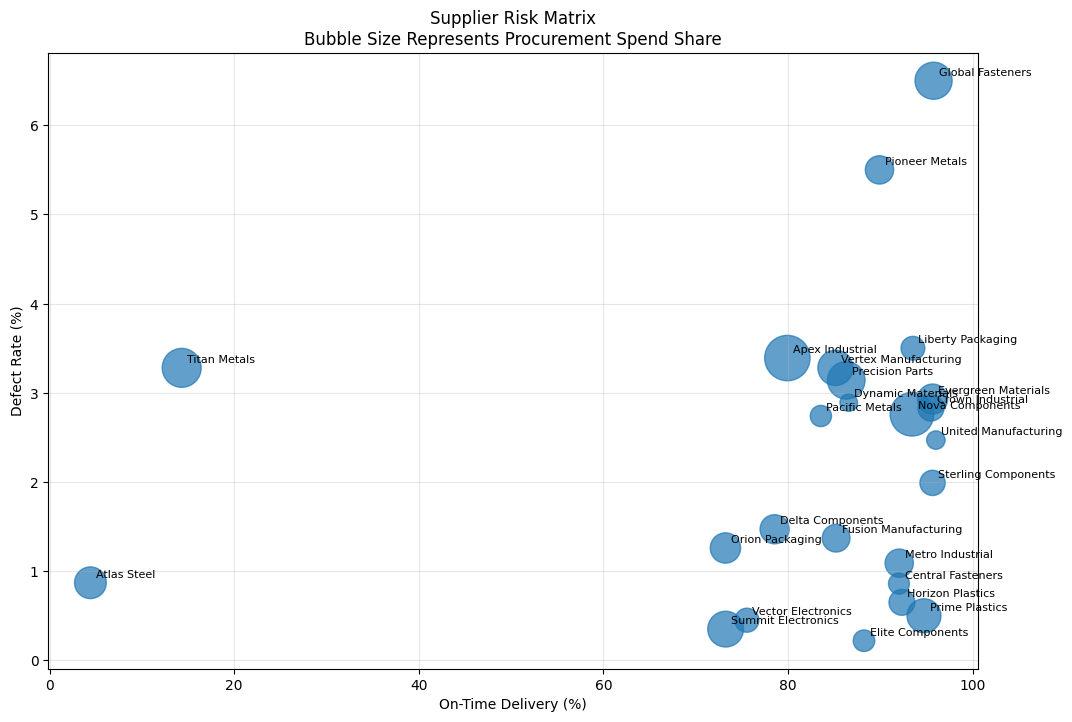

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    supplier_scorecard["on_time_delivery_pct"],
    supplier_scorecard["defect_rate_pct"],
    s=supplier_scorecard["spend_share_pct"] * 120,
    alpha=0.7
)

for _, row in supplier_scorecard.iterrows():

    plt.annotate(
        row["supplier_name"],
        (
            row["on_time_delivery_pct"],
            row["defect_rate_pct"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("On-Time Delivery (%)")
plt.ylabel("Defect Rate (%)")

plt.title(
    "Supplier Risk Matrix\n"
    "Bubble Size Represents Procurement Spend Share"
)

plt.grid(alpha=0.3)

plt.show()

This one chart tells a fantastic story:
- farther right = better delivery
- higher = worse quality
- larger bubble = more money exposed
So a large bubble in the upper-left is exactly the kind of supplier Procurement should worry about.

Titan Metals and Atlas Steel are far to the left because of severe delivery problems; Global Fasteners and Pioneer Metals are high on the chart because of elevated defect rates; Apex Industrial has a large bubble because of high spend exposure; and Summit Electronics looks relatively good on quality but has the major pricing problem we identified separately.
At this point, we can lock the analysis and write the executive findings. I’d use these five:
1. Delivery risk — Titan Metals & Atlas Steel: Titan Metals is around 14% on-time and Atlas Steel around 4%, despite meaningful procurement spend. Recommendation: corrective-action plan, tighter delivery SLAs, and alternate-source evaluation.
2. Quality risk — Global Fasteners: roughly 6.5% defect rate, the highest among major suppliers. Recommendation: supplier quality review, root-cause analysis, and defect-reduction targets.
3. Quality risk — Pioneer Metals: roughly 5.5% defects despite much stronger delivery performance. Recommendation: retain delivery relationship but require quality-improvement actions.
4. Pricing risk — Summit Electronics: roughly +13.9% average price variance versus standard, making it the clearest commercial-cost concern. Recommendation: renegotiation, should-cost analysis, or competitive sourcing review.
5. Strategic exposure — Apex Industrial: your largest/highest-spend supplier, with roughly 80% on-time delivery, ~3.4% defects, and about +5% price variance. It may not be the worst supplier operationally, but because so much money is exposed to it, it deserves strategic monitoring.

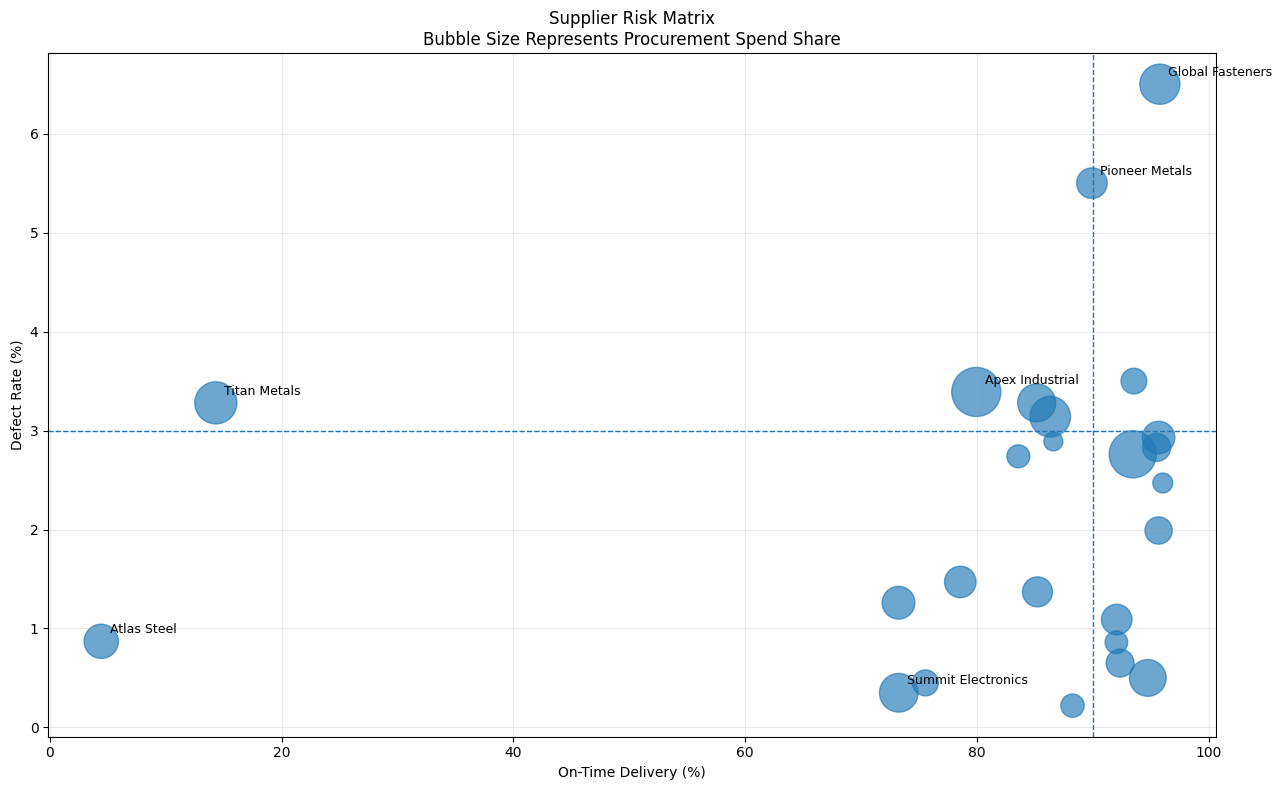

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 8))

plt.scatter(
    supplier_scorecard["on_time_delivery_pct"],
    supplier_scorecard["defect_rate_pct"],
    s=supplier_scorecard["spend_share_pct"] * 140,
    alpha=0.65
)

# Label only suppliers that matter most
label_suppliers = [
    "Titan Metals",
    "Atlas Steel",
    "Global Fasteners",
    "Pioneer Metals",
    "Summit Electronics",
    "Apex Industrial"
]

for _, row in supplier_scorecard.iterrows():

    if row["supplier_name"] in label_suppliers:

        plt.annotate(
            row["supplier_name"],
            (
                row["on_time_delivery_pct"],
                row["defect_rate_pct"]
            ),
            fontsize=9,
            xytext=(6, 6),
            textcoords="offset points"
        )

# Reference thresholds
plt.axvline(
    x=90,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    y=3,
    linestyle="--",
    linewidth=1
)

plt.xlabel("On-Time Delivery (%)")
plt.ylabel("Defect Rate (%)")

plt.title(
    "Supplier Risk Matrix\n"
    "Bubble Size Represents Procurement Spend Share"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "supplier_risk_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()